# Reproducing Diebold-Yilmaz (2012)

**Diebold, F. X. & Yilmaz, K. (2012).** *Better to Give than to Receive: Predictive Directional Measurement of Volatility Spillovers.* **International Journal of Forecasting, 28(1), 57–66.**

This notebook uses PyConnecteedness package to reconstruct the full-sample **volatility spillover table** of the 2012 paper (Table 2) and reproduce its headline number: a total spillover index of **12.6 %** across four asset classes.

The key methodological change from the 2009 paper is the **generalized** (Koop–Pesaran–Potter / Pesaran–Shin 1998) variance decomposition, which is **invariant to the ordering** of the variables. All results below use `method="generalized"`.

In [2]:
import os
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

from pyconnectedness import static_connectedness, dynamic_connectedness

# paths below are relative to the repository root
while not os.path.isdir("examples") and os.path.basename(os.getcwd()):
    os.chdir("..")

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)

### Data 

**2771 daily observations** on four U.S. asset classes (Diebold–Yilmaz 2012), 25 Jan 1999 – 29 Jan 2010:

- `sp500` — stocks (S&P 500)
- `r_10y` — bonds (10-year Treasury)
- `dj_ubs_com` — commodities (DJ-UBS commodity index)
- `usdx` — FX (US dollar index)

The paper models **log volatility**, not the raw variance series. This is easy to miss: feeding the raw values through the VAR runs without any error but gives the wrong index (~19 % instead of 12.6 %). We take the natural log immediately after loading and confirm the trap at the end.

In [3]:
raw_vola = pd.read_excel("examples/data/dy2012_vola.xlsx").set_index("date")
log_vola = np.log(raw_vola)

print("Assets:", list(log_vola.columns))
print("Observations:", len(log_vola), "| Missing:", int(log_vola.isna().sum().sum()))
print("Sample:", log_vola.index.min().date(), "->", log_vola.index.max().date())

Assets: ['sp500', 'r_10y', 'dj_ubs_com', 'usdx']
Observations: 2771 | Missing: 0
Sample: 1999-01-25 -> 2010-01-29


## Table 1 - Descriptive Statistics 

Diebold–Yilmaz (2012), Table 1. As in the 2009 paper, kurtosis is **raw** (`fisher=False`) and skewness/kurtosis use the **population (biased)** estimator (`bias=True`).

In [4]:
table1 = pd.DataFrame({
    "Mean":     log_vola.mean(),
    "Median":   log_vola.median(),
    "Maximum":  log_vola.max(),
    "Minimum":  log_vola.min(),
    "Std.Dev.": log_vola.std(ddof=1),
    "Skewness": pd.Series(stats.skew(log_vola, bias=True), index=log_vola.columns),
    "Kurtosis": pd.Series(stats.kurtosis(log_vola, fisher=False, bias=True), index=log_vola.columns),
}).T
table1.round(4)

,sp500,r_10y,dj_ubs_com,usdx
Mean,-9.7042,-9.4364,-10.6901,-11.0045
Median,-9.7430,-9.4389,-10.5025,-10.9901
Maximum,-5.4509,-4.2274,-6.3435,-7.6186
Minimum,-13.0902,-13.7876,-18.3283,-16.8633
Std.Dev.,1.1856,1.1921,1.5415,0.9765
Skewness,0.2143,0.0193,-0.7332,-0.2146
Kurtosis,3.1827,3.1595,4.2080,3.8725


## The generalized spillover index

Starting from the same $\mathrm{VAR}(p)$ and its moving-average form $x_t = \sum_{h=0}^{\infty} A_h \varepsilon_{t-h}$, the **generalized** $H$-step forecast-error variance decomposition (Pesaran–Shin 1998) is

$$\theta_{ij}^{g}(H)=
\frac{\sigma_{jj}^{-1}\sum_{h=0}^{H-1}\big(e_i' A_h \Sigma\, e_j\big)^2}
{\sum_{h=0}^{H-1} e_i' A_h \Sigma A_h' e_i},$$

where $\sigma_{jj}$ is the $j$-th diagonal element of $\Sigma$. Because the shocks are correlated the rows do **not** sum to one, so each entry is normalized by its row sum,

$$\tilde\theta_{ij}^{g}(H)=\frac{\theta_{ij}^{g}(H)}{\sum_{j=1}^{K}\theta_{ij}^{g}(H)},
\qquad \sum_{j}\tilde\theta_{ij}^{g}(H)=1 .$$

The **total spillover index** is again the off-diagonal share,

$$S^{g}(H)=\frac{\sum_{i\neq j}\tilde\theta_{ij}^{g}(H)}{K}\times 100 .$$

The paper uses a $\mathrm{VAR}(4)$ and a $10$-day-ahead horizon (Table 2, note 6), so `method="generalized"`, `lags=4`, `horizon=10`.

## Table 2 - Volatility spillover table, four asset classes


The full-sample spillover table. The corner of the `TO_incl_own` row is the **total volatility spillover index - the paper reports 12.6 %.**

In [5]:
conn = static_connectedness (log_vola, horizon=10, method="generalized", lags=4)
print ("total volatility spillover index - pyconnectedness:", round(conn.total,2), "% (paper:12.6%)")

total volatility spillover index - pyconnectedness: 12.59 % (paper:12.6%)


c:\Users\Zoran\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


:check 

In [6]:
conn.table.round(2)

,sp500,r_10y,dj_ubs_com,usdx,FROM
sp500,88.76,7.29,0.35,3.61,11.24
r_10y,10.21,81.45,2.73,5.61,18.55
dj_ubs_com,0.47,3.70,93.69,2.14,6.31
usdx,5.69,7.03,1.55,85.73,14.27
TO,16.37,18.01,4.62,11.36,50.37
TO_incl_own,105.13,99.46,98.31,97.10,12.59
NET,5.13,-0.54,-1.69,-2.90,0.00


### The log-volatility trap

For contrast, the same call on the **raw** (un-logged) volatility series. It runs without complaint but overstates the index by a wide margin — a reminder to always model log volatility.

In [8]:
conn_raw = static_connectedness(raw_vola, horizon=10, method="generalized", lags=4)
print("log volatility -> TCI =", round(conn.total, 2), "%   (correct, paper 12.6%)")
print("raw volatility -> TCI =", round(conn_raw.total, 2), "%")

log volatility -> TCI = 12.59 %   (correct, paper 12.6%)
raw volatility -> TCI = 16.48 %


c:\Users\Zoran\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


# Directional spillovers over time

Rolling the generalized decomposition over a **200-day window** gives the time-varying directional measures: `directional_from` (received *from* others, Figure 3) and `directional_to` (transmitted *to* others, Figure 4). Both climb sharply through the 2007–2009 crisis.

In [9]:
dyn = dynamic_connectedness (log_vola, window = 200, horizon = 10, method = "generalized", lags =4)

c:\Users\Zoran\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Zoran\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Zoran\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Zoran\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been pro

In [10]:
N = len(dyn.names)
i_st = dyn.names.index("sp500")
i_bo = dyn.names.index("r_10y")
i_co = dyn.names.index("dj_ubs_com")
i_fx = dyn.names.index("usdx")

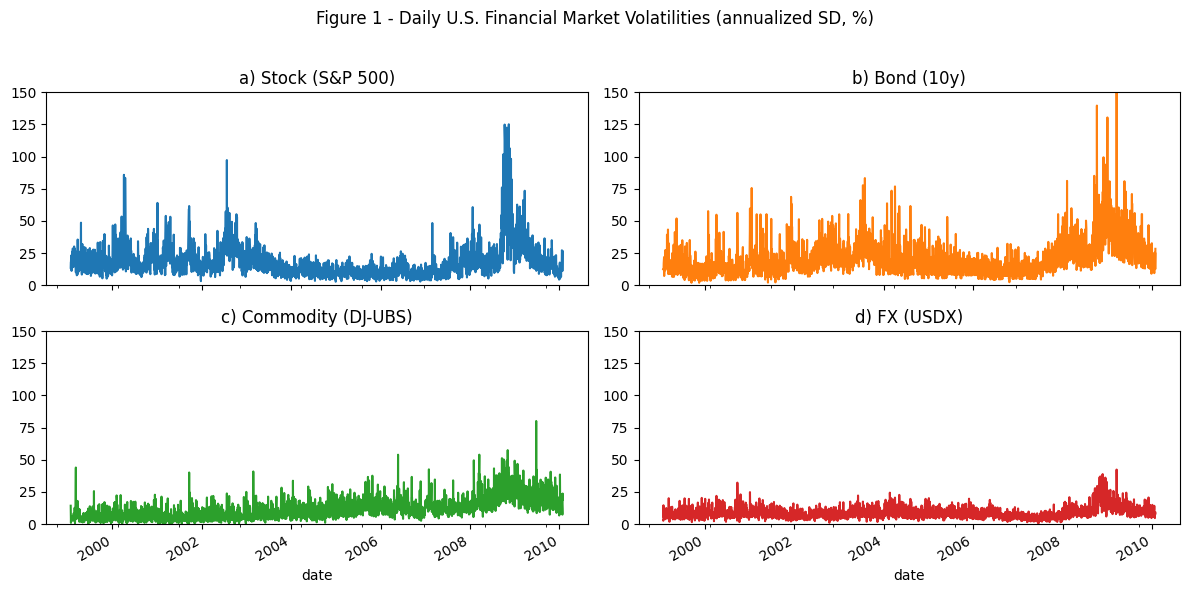

In [11]:
# Fig 1 - daily vola (yearly SD, %)
annual_vol = 100 * np.sqrt(365 * raw_vola) # check 365 
annual_vol.plot(subplots=True, layout=(2, 2), figsize=(12, 6), legend=False, ylim=(0, 150),
                title=["a) Stock (S&P 500)", "b) Bond (10y)", "c) Commodity (DJ-UBS)", "d) FX (USDX)"])
plt.suptitle("Figure 1 - Daily U.S. Financial Market Volatilities (annualized SD, %)")
plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

In [12]:
dyn.directional_to

,sp500,r_10y,dj_ubs_com,usdx
date,,,,
1999-11-05,17.436208,19.732861,7.805228,9.050588
1999-11-08,17.172771,20.530437,8.401407,8.321232
1999-11-09,17.480696,20.310964,7.544346,7.342711
1999-11-10,17.677246,19.908660,7.513109,7.100182
1999-11-11,17.716967,18.620759,7.537469,7.962353
...,...,...,...,...
2010-01-25,28.461939,16.384165,8.320322,16.973936
2010-01-26,29.054159,17.460041,8.481066,17.998135
2010-01-27,28.746555,18.098451,8.760995,17.394980


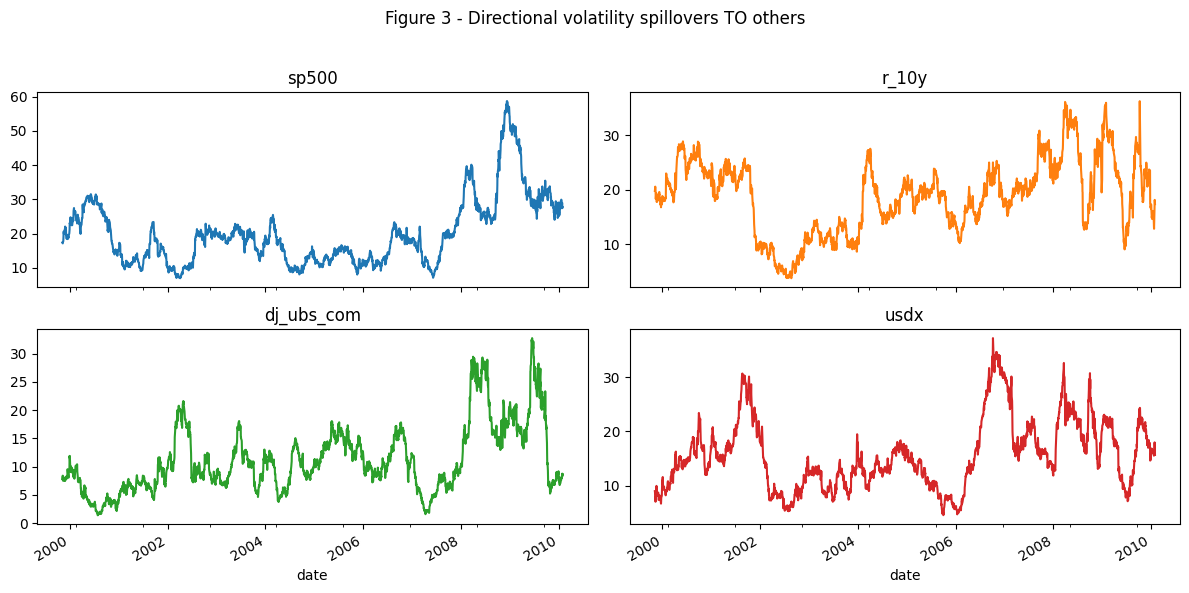

In [13]:
# Fig 3
(dyn.directional_to).plot(subplots=True, layout=(2, 2), figsize=(12, 6), legend=False,
                              title=list(dyn.directional_to.columns))
plt.suptitle("Figure 3 - Directional volatility spillovers TO others")
plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()


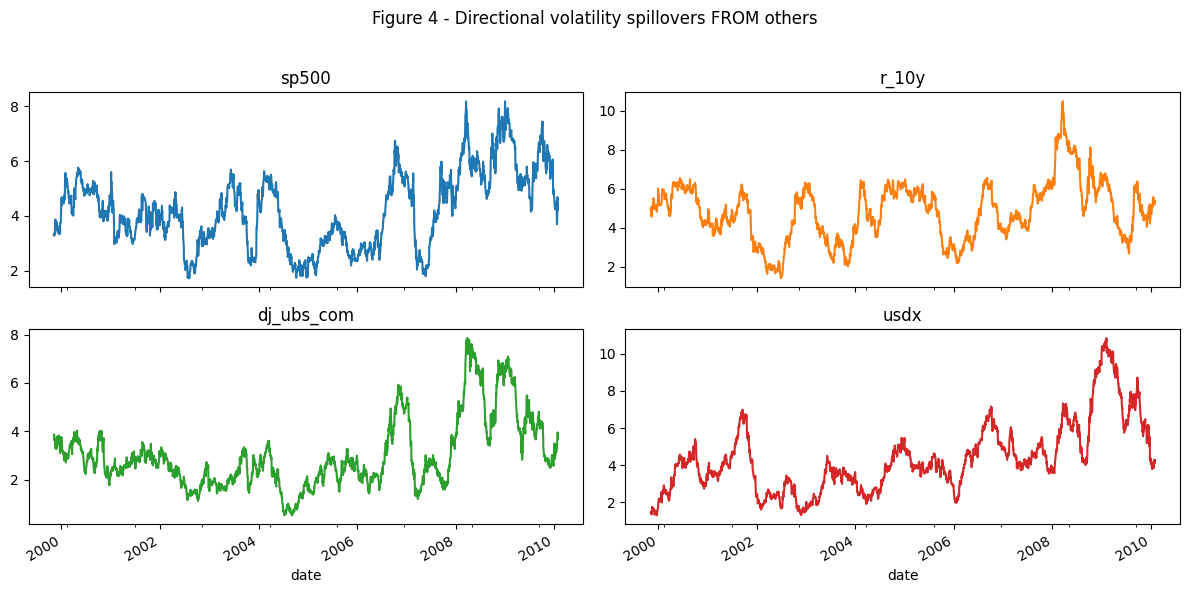

In [14]:
# Fig 4
(dyn.directional_from / N).plot(subplots=True, layout=(2, 2), figsize=(12, 6), legend=False,
                              title=list(dyn.directional_from.columns))
plt.suptitle("Figure 4 - Directional volatility spillovers FROM others")
plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

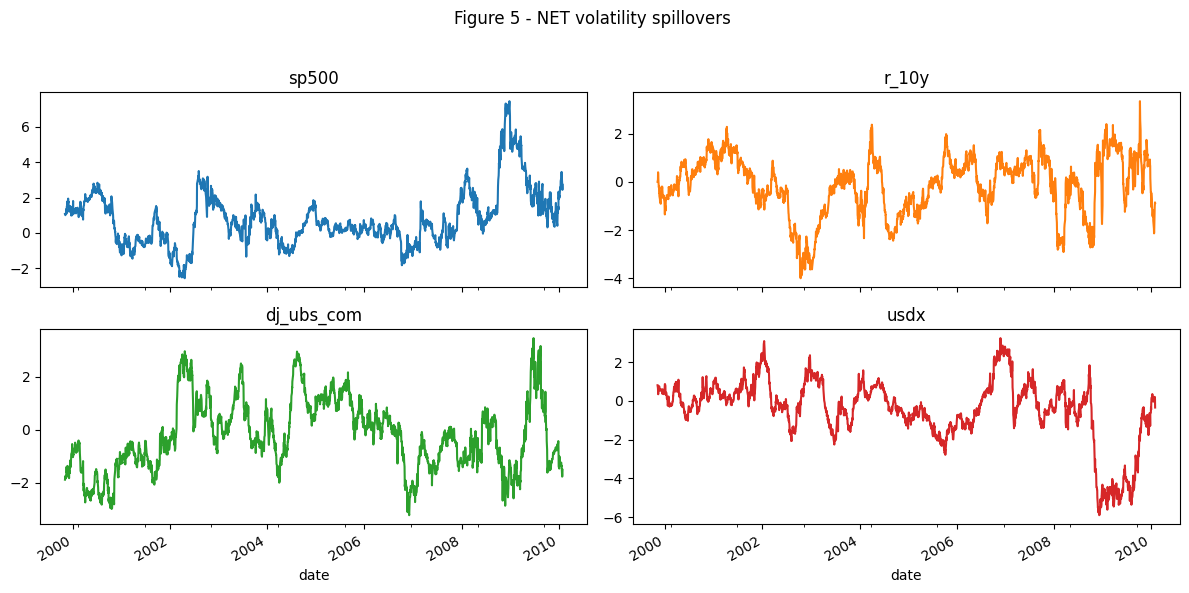

In [15]:
# Fig 5
(dyn.net / N).plot(subplots=True, layout=(2, 2), figsize=(12, 6), legend=False,
                              title=list(dyn.net.columns))
plt.suptitle("Figure 5 - NET volatility spillovers ")
plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

## NET pairwise spillovers

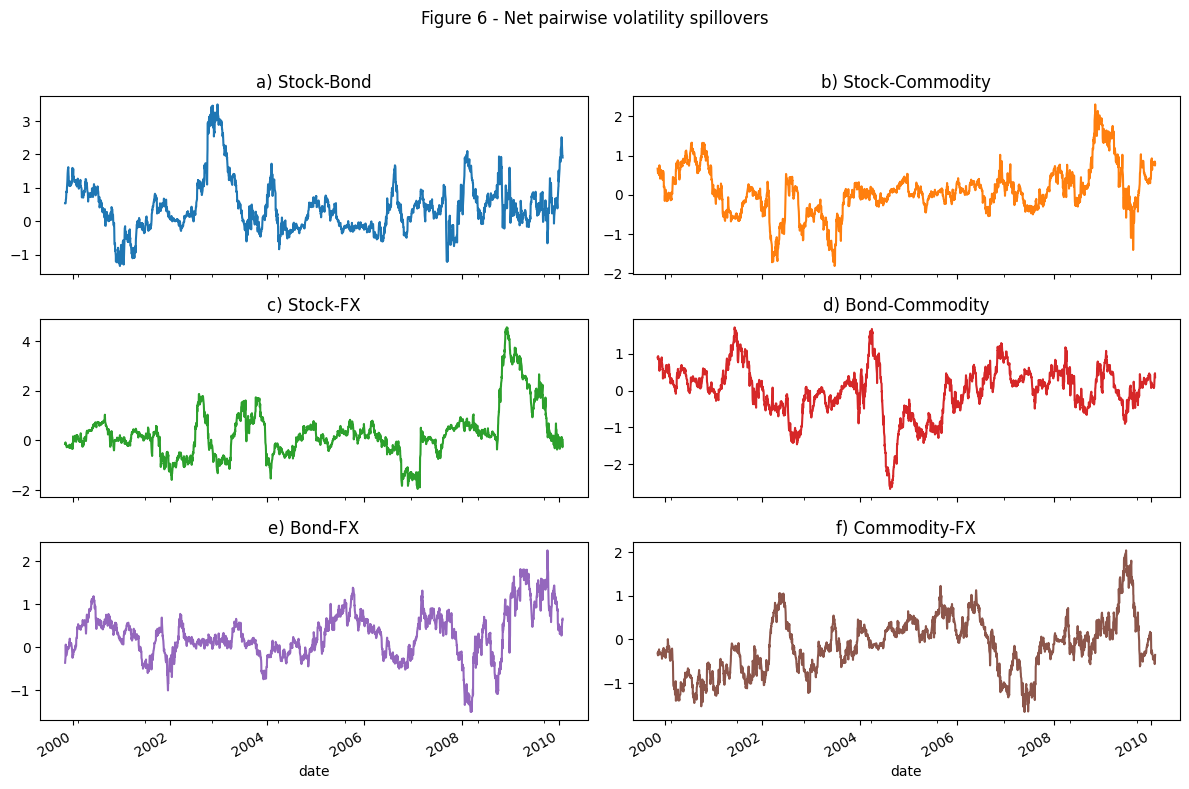

In [16]:
# Figure 6 - Net Pairwise Spillovers (alle 6 Paare). Vorzeichen: positiv = der erstgenannte Markt ist Netto-Sender
net_pairwise = pd.DataFrame({
    "a) Stock-Bond":      dyn.fevd[:, i_bo, i_st] - dyn.fevd[:, i_st, i_bo],
    "b) Stock-Commodity": dyn.fevd[:, i_co, i_st] - dyn.fevd[:, i_st, i_co],
    "c) Stock-FX":        dyn.fevd[:, i_fx, i_st] - dyn.fevd[:, i_st, i_fx],
    "d) Bond-Commodity":  dyn.fevd[:, i_co, i_bo] - dyn.fevd[:, i_bo, i_co],
    "e) Bond-FX":         dyn.fevd[:, i_fx, i_bo] - dyn.fevd[:, i_bo, i_fx],
    "f) Commodity-FX":    dyn.fevd[:, i_fx, i_co] - dyn.fevd[:, i_co, i_fx],
}, index=dyn.total.index) / N
net_pairwise.plot(subplots=True, layout=(3, 2), figsize=(12, 8), legend=False,
                  title=list(net_pairwise.columns))
plt.suptitle("Figure 6 - Net pairwise volatility spillovers")
plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

## Total spillover index over time

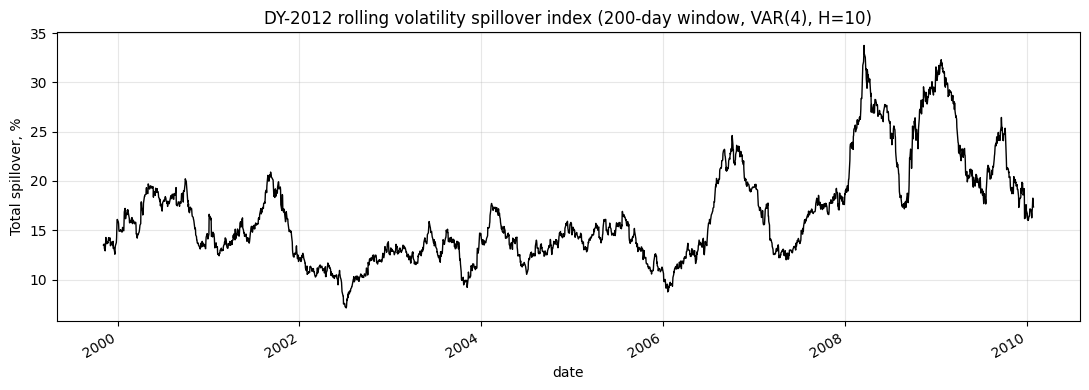

In [17]:
fig, ax = plt.subplots(figsize=(11, 4))
dyn.total.plot(ax=ax, color="black", lw=1)
ax.set_title("DY-2012 rolling volatility spillover index (200-day window, VAR(4), H=10)")
ax.set_ylabel("Total spillover, %")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Net pairwise volatility spillovers (Figure 6)

The **net pairwise** spillover between markets $i$ and $j$,

$$C_{ij} = \big(\tilde\theta_{ji}^{g} - \tilde\theta_{ij}^{g}\big)\times 100,$$

is antisymmetric ($C_{ij} = -C_{ji}$): a positive value means $i$ is the net transmitter to $j$. `DynamicConnectednessResult` keeps the per-window decompositions in `.fevd` (shape `T × k × k`, already in %), so the net-pairwise series for any pair is a plain difference of two slices - no refitting. Below:
**stocks vs. bonds** and **stocks vs. FX** through time.

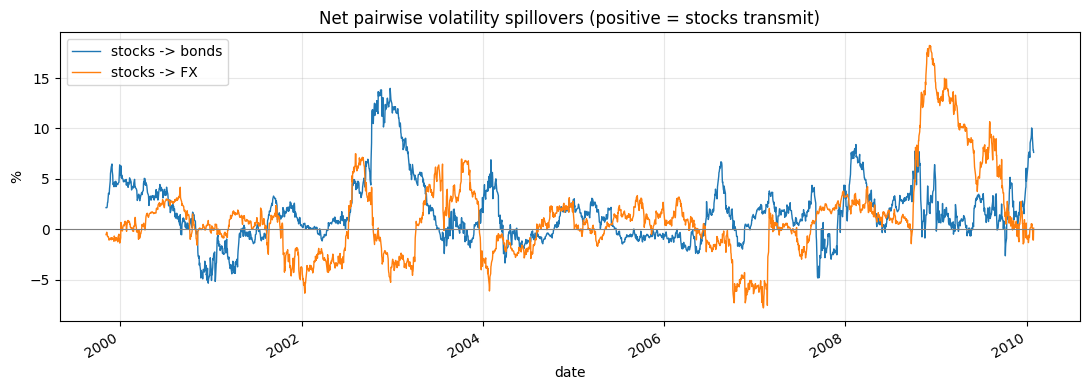

In [18]:
names = dyn.names
i_stocks, i_bonds, i_fx = names.index("sp500"), names.index("r_10y"), names.index("usdx")

net_stocks_bonds = pd.Series(dyn.fevd[:, i_bonds, i_stocks] - dyn.fevd[:, i_stocks, i_bonds],
                             index=dyn.total.index, name="stocks -> bonds")
net_stocks_fx = pd.Series(dyn.fevd[:, i_fx, i_stocks] - dyn.fevd[:, i_stocks, i_fx],
                          index=dyn.total.index, name="stocks -> FX")

fig, ax = plt.subplots(figsize=(11, 4))
net_stocks_bonds.plot(ax=ax, lw=1)
net_stocks_fx.plot(ax=ax, lw=1)
ax.axhline(0, color="grey", lw=0.8)
ax.set_title("Net pairwise volatility spillovers (positive = stocks transmit)")
ax.set_ylabel("%")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

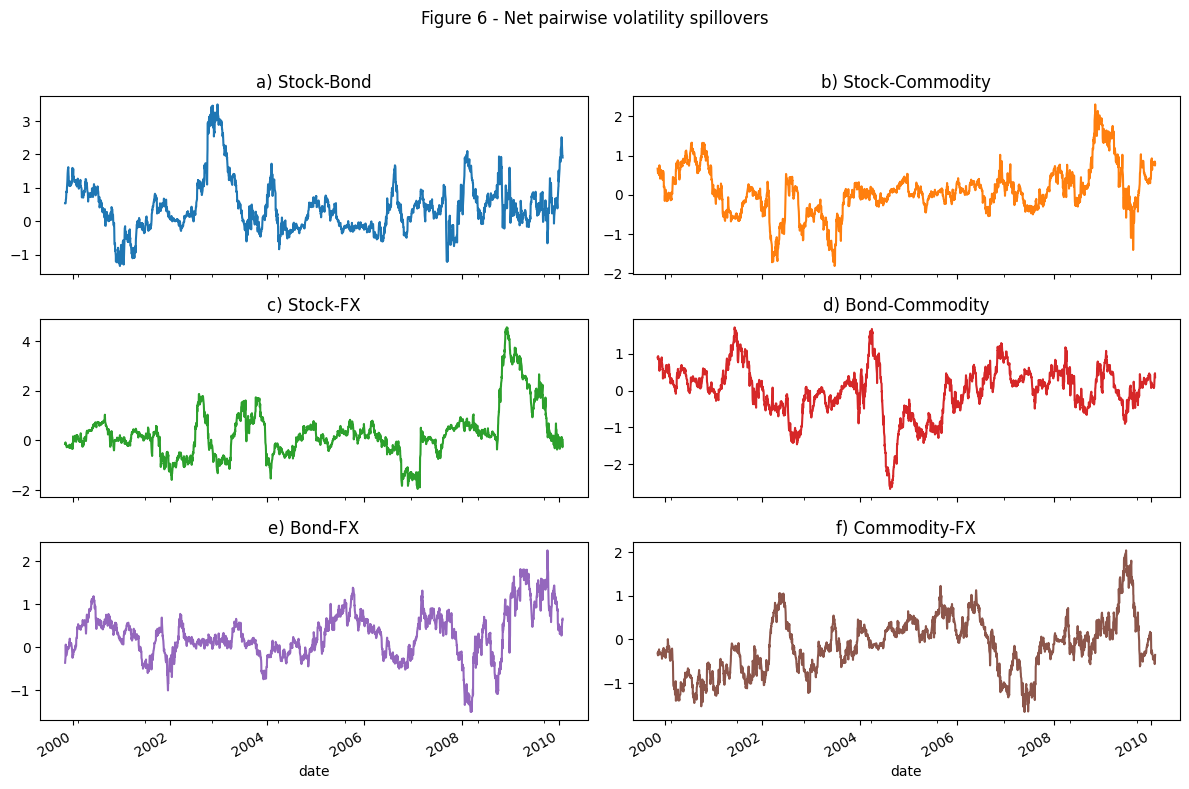

In [19]:
# Figure 6 - Net Pairwise Spillovers (alle 6 Paare). Vorzeichen: positiv = der erstgenannte Markt ist Netto-Sender
net_pairwise = pd.DataFrame({
    "a) Stock-Bond":      dyn.fevd[:, i_bo, i_st] - dyn.fevd[:, i_st, i_bo],
    "b) Stock-Commodity": dyn.fevd[:, i_co, i_st] - dyn.fevd[:, i_st, i_co],
    "c) Stock-FX":        dyn.fevd[:, i_fx, i_st] - dyn.fevd[:, i_st, i_fx],
    "d) Bond-Commodity":  dyn.fevd[:, i_co, i_bo] - dyn.fevd[:, i_bo, i_co],
    "e) Bond-FX":         dyn.fevd[:, i_fx, i_bo] - dyn.fevd[:, i_bo, i_fx],
    "f) Commodity-FX":    dyn.fevd[:, i_fx, i_co] - dyn.fevd[:, i_co, i_fx],
}, index=dyn.total.index) / N
net_pairwise.plot(subplots=True, layout=(3, 2), figsize=(12, 8), legend=False,
                  title=list(net_pairwise.columns))
plt.suptitle("Figure 6 - Net pairwise volatility spillovers")
plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

## Summary

| Result | `pyconnectedness` | Diebold–Yilmaz (2012) |
|---|---|---|
| Total volatility spillover index (Table 2) | **12.6%** | **12.6 %** |

The 12.6 % index reproduces with a generalized VAR(4) and a 10-day horizon **on log volatility**.  The generalized decomposition is order-invariant, unlike the 2009 return index in `replicate_dy2009.ipynb`.